No path specified. Models will be saved in: "AutogluonModels/ag-20260422_163539"


                 model  score_val  score_test
0      LightGBM_BAG_L1 -25.365906  -19.210358
1  WeightedEnsemble_L2 -25.365906  -19.210358
2    LightGBMXT_BAG_L1 -27.360607  -22.534050
3    LightGBMXT_BAG_L2 -25.215023  -23.005066
4  WeightedEnsemble_L3 -25.215023  -23.005066
Train R²: 0.9967
Test  R²: 0.9903
R² Gap (Train - Test): 0.0064
Train RMSE: 12.9029
Test  RMSE: 23.0051
RMSE Gap (Test - Train): 10.1022


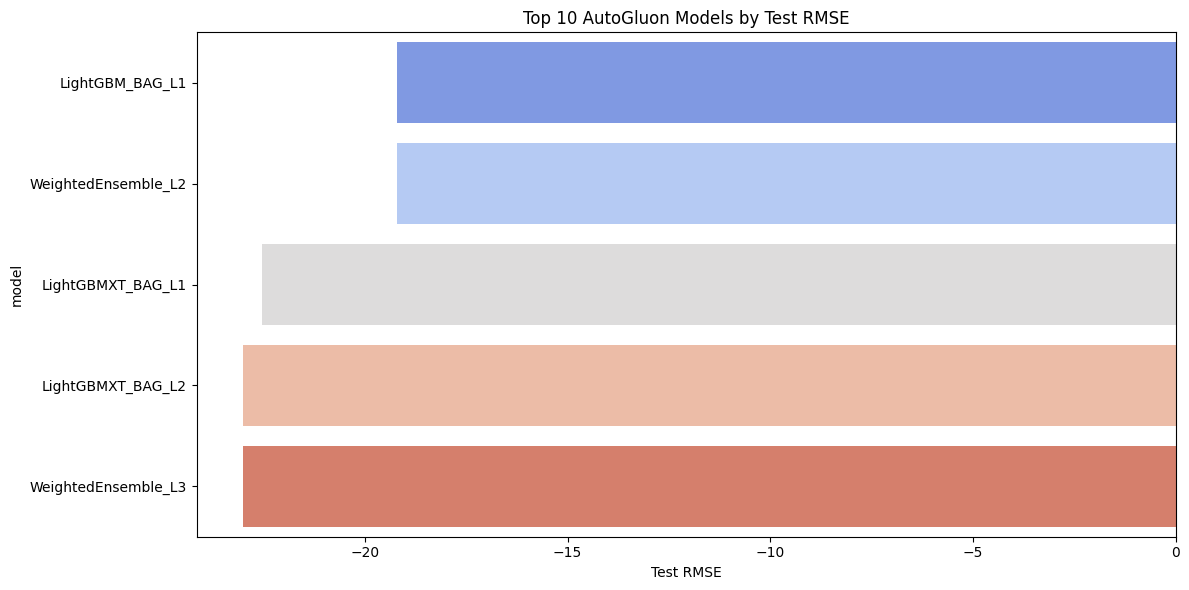

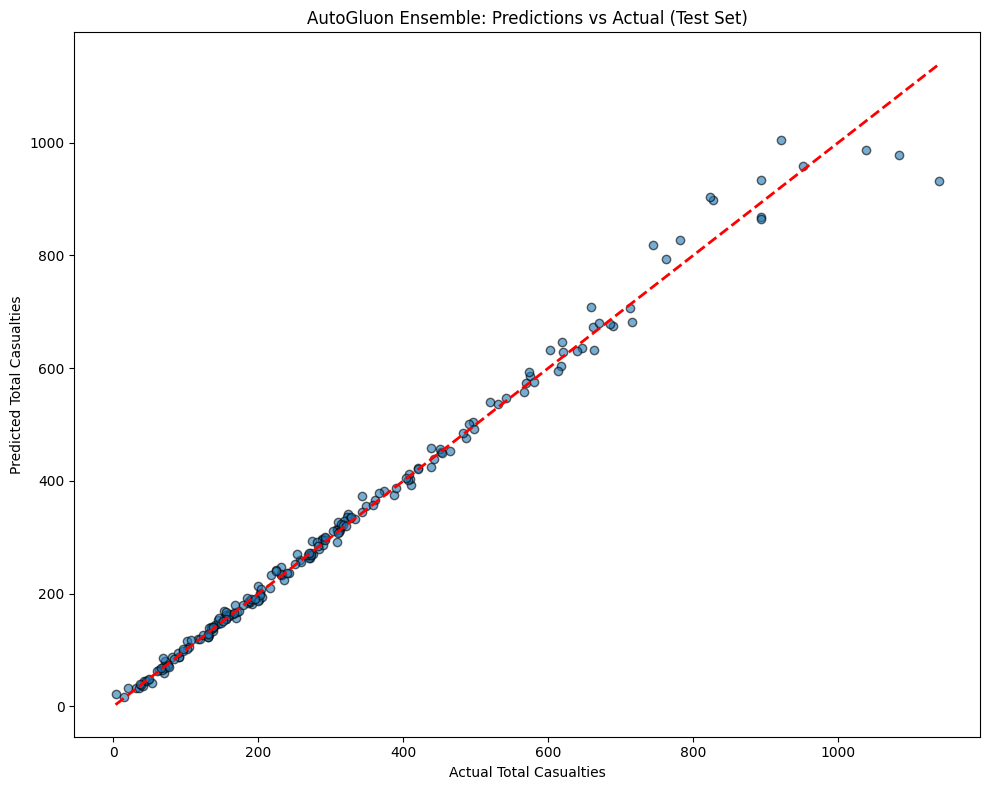

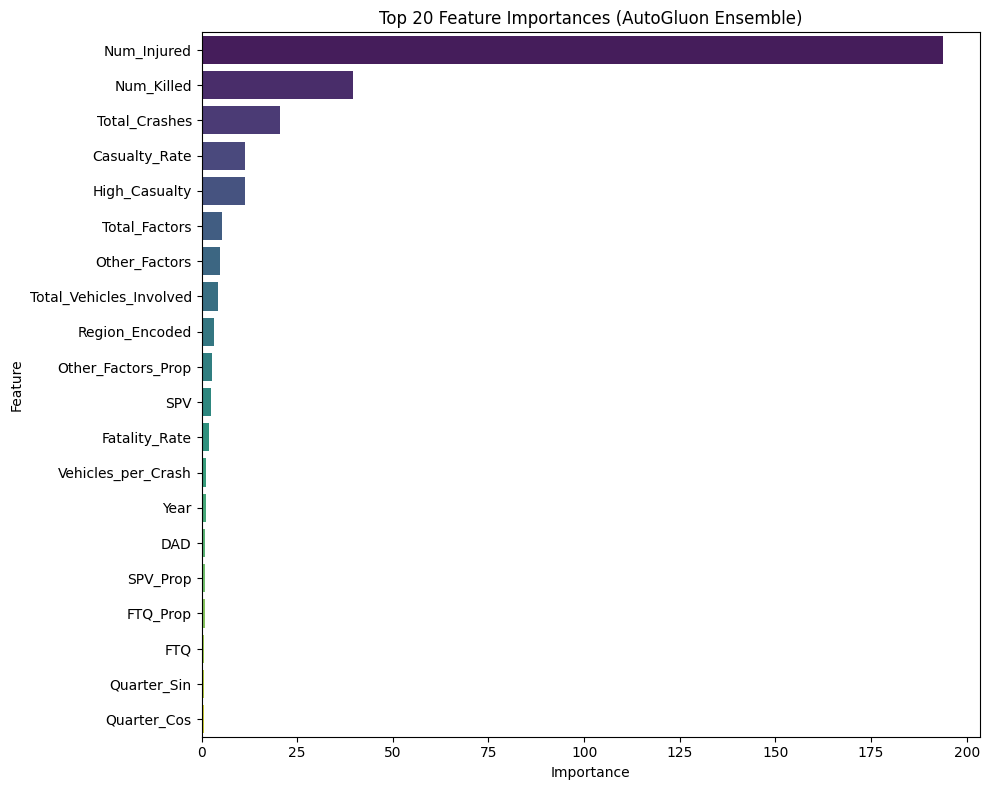

In [3]:
import subprocess
import sys
try:
    from autogluon.tabular import TabularDataset, TabularPredictor
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "autogluon"])
    from autogluon.tabular import TabularDataset, TabularPredictor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Augmented Dataset of Nigeria Crash.csv')
drop_cols = ['Quarter', 'State', 'Quarter_Date', 'State_Encoded']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
state_dummies = [c for c in df.columns if c.startswith('State_')]
df.drop(columns=state_dummies, inplace=True)
df = df.select_dtypes(include=[np.number])
df.dropna(inplace=True)
target = 'Total_Casualties'
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)
train_data = TabularDataset(train_data)
test_data = TabularDataset(test_data)
predictor = TabularPredictor(label=target, problem_type='regression', eval_metric='rmse')
predictor.fit(train_data, time_limit=300, presets='best_quality', verbosity=0)
leaderboard = predictor.leaderboard(test_data, silent=True)
print(leaderboard[['model', 'score_val', 'score_test']].head())
y_train_pred = predictor.predict(train_data.drop(columns=[target]))
y_test_pred = predictor.predict(test_data.drop(columns=[target]))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
gap_r2 = train_r2 - test_r2
gap_rmse = test_rmse - train_rmse
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")
print(f"R² Gap (Train - Test): {gap_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
print(f"RMSE Gap (Test - Train): {gap_rmse:.4f}")
model_performance = leaderboard[['model', 'score_test']].dropna().sort_values('score_test', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(data=model_performance.head(10), x='score_test', y='model', palette='coolwarm')
plt.xlabel('Test RMSE')
plt.title('Top 10 AutoGluon Models by Test RMSE')
plt.tight_layout()
plt.savefig('autogluon_model_comparison.png', dpi=150)
plt.show()
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Total Casualties')
plt.ylabel('Predicted Total Casualties')
plt.title('AutoGluon Ensemble: Predictions vs Actual (Test Set)')
plt.tight_layout()
plt.savefig('autogluon_predictions.png', dpi=150)
plt.show()
feature_importance = predictor.feature_importance(train_data, silent=True)
if feature_importance is not None and len(feature_importance) > 0:
    if isinstance(feature_importance, pd.DataFrame):
        if 'importance' in feature_importance.columns:
            fi_df = feature_importance[['importance']].reset_index()
            fi_df.columns = ['Feature', 'Importance']
        elif 'score' in feature_importance.columns:
            fi_df = feature_importance[['score']].reset_index()
            fi_df.columns = ['Feature', 'Importance']
        else:
            fi_df = feature_importance.reset_index()
            if fi_df.shape[1] == 2:
                fi_df.columns = ['Feature', 'Importance']
            else:
                fi_df = fi_df.iloc[:, [0, 1]]
                fi_df.columns = ['Feature', 'Importance']
    else:
        fi_df = pd.DataFrame({'Feature': feature_importance.index, 'Importance': feature_importance.values})
    fi_df = fi_df.sort_values('Importance', ascending=False)
    plt.figure(figsize=(10, 8))
    sns.barplot(data=fi_df.head(20), x='Importance', y='Feature', palette='viridis')
    plt.title('Top 20 Feature Importances (AutoGluon Ensemble)')
    plt.tight_layout()
    plt.savefig('autogluon_feature_importance.png', dpi=150)
    plt.show()
else:
    print("Feature importance not available or empty.")